In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
df = pd.read_csv("data/Credit_Card_Applications.csv")
df.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [88]:
df.shape


(690, 16)

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB


In [90]:
df.isnull().sum()

CustomerID    0
A1            0
A2            0
A3            0
A4            0
A5            0
A6            0
A7            0
A8            0
A9            0
A10           0
A11           0
A12           0
A13           0
A14           0
Class         0
dtype: int64

In [91]:
df.describe()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
count,6.900000e+02,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000,690.000000
mean,1.569047e+07,0.678261,31.568203,4.758725,1.766667,7.372464,4.692754,2.223406,0.523188,0.427536,2.40000,0.457971,1.928986,184.014493,1018.385507,0.444928
std,7.150647e+04,0.467482,11.853273,4.978163,0.430063,3.683265,1.992316,3.346513,0.499824,0.495080,4.86294,0.498592,0.298813,172.159274,5210.102598,0.497318
min,1.556571e+07,0.000000,13.750000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,1.563169e+07,0.000000,22.670000,1.000000,2.000000,4.000000,4.000000,0.165000,0.000000,0.000000,0.00000,0.000000,2.000000,80.000000,1.000000,0.000000
50%,1.569016e+07,1.000000,28.625000,2.750000,2.000000,8.000000,4.000000,1.000000,1.000000,0.000000,0.00000,0.000000,2.000000,160.000000,6.000000,0.000000
75%,1.575190e+07,1.000000,37.707500,7.207500,2.000000,10.000000,5.000000,2.625000,1.000000,1.000000,3.00000,1.000000,2.000000,272.000000,396.500000,1.000000
max,1.581544e+07,1.000000,80.250000,28.000000,3.000000,14.000000,9.000000,28.500000,1.000000,1.000000,67.00000,1.000000,3.000000,2000.000000,100001.000000,1.000000


In [92]:
df['Class'].value_counts()

Class
0    383
1    307
Name: count, dtype: int64

In [93]:
df['Class'].value_counts(normalize=True) * 100

Class
0    55.507246
1    44.492754
Name: proportion, dtype: float64

In [94]:
df.groupby('Class').mean()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
Class,,,,,,,,,,,,,,,
0,1.568821e+07,0.684073,29.854230,3.839948,1.691906,6.140992,4.253264,1.257924,0.201044,0.224543,0.631854,0.443864,1.898172,199.412533,199.605744
1,1.569330e+07,0.671010,33.706482,5.904951,1.859935,8.908795,5.241042,3.427899,0.925081,0.680782,4.605863,0.475570,1.967427,164.804560,2039.859935


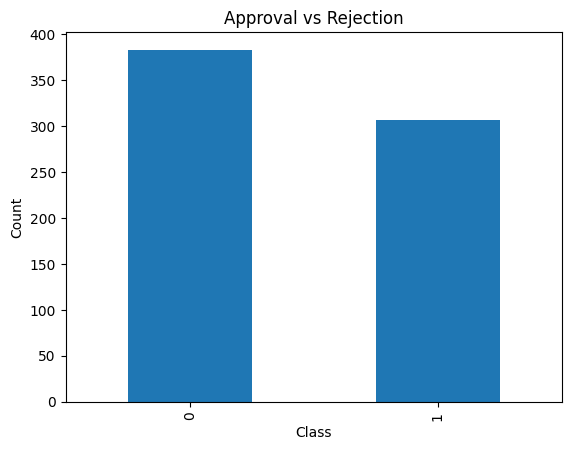

In [95]:

df['Class'].value_counts().plot(kind='bar')
plt.title("Approval vs Rejection")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [96]:
approval_diff = (df.groupby('Class').mean().loc[1] - df.groupby('Class').mean().loc[0]).sort_values(ascending=False)
approval_diff

CustomerID    5089.914867
A14           1840.254191
A10              3.974009
A2               3.852252
A5               2.767803
A7               2.169975
A3               2.065003
A6               0.987779
A8               0.724037
A9               0.456239
A4               0.168029
A12              0.069254
A11              0.031706
A1              -0.013063
A13            -34.607972
dtype: float64

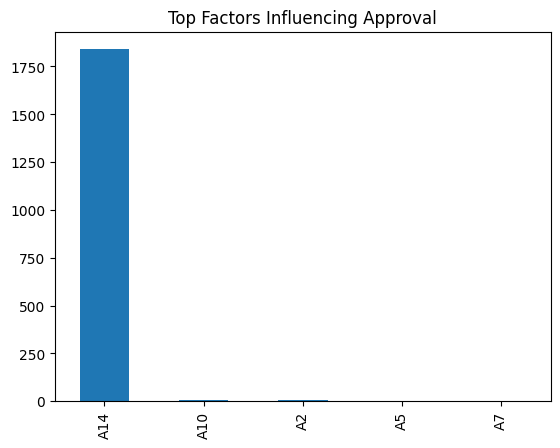

In [97]:
approval_diff.drop('CustomerID').head(5).plot(kind='bar')
plt.title("Top Factors Influencing Approval")
plt.show()

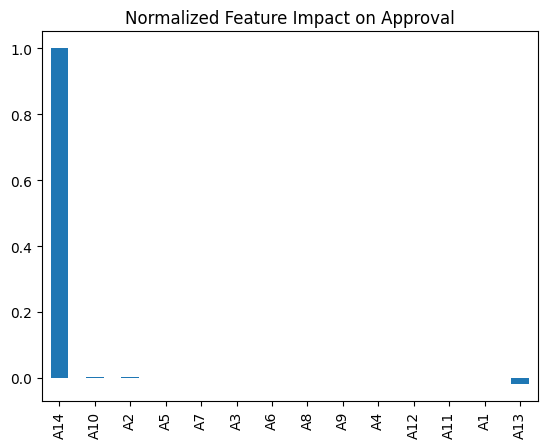

In [98]:
diff = df.groupby('Class').mean().loc[1] - df.groupby('Class').mean().loc[0]
diff = diff.drop('CustomerID')
diff_normalized = diff / diff.abs().max()

diff_normalized.sort_values(ascending=False).plot(kind='bar')
plt.title("Normalized Feature Impact on Approval")
plt.show()

In [99]:
risk_diff = (df.groupby('Class').mean().loc[0] - df.groupby('Class').mean().loc[1]).sort_values(ascending=False)
risk_diff

A13             34.607972
A1               0.013063
A11             -0.031706
A12             -0.069254
A4              -0.168029
A9              -0.456239
A8              -0.724037
A6              -0.987779
A3              -2.065003
A7              -2.169975
A5              -2.767803
A2              -3.852252
A10             -3.974009
A14          -1840.254191
CustomerID   -5089.914867
dtype: float64

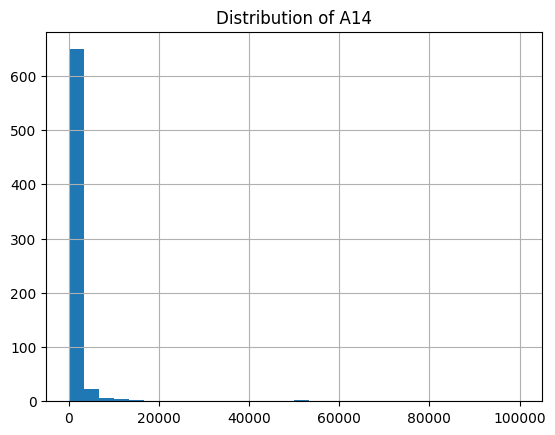

In [100]:
df['A14'].hist(bins=30)
plt.title("Distribution of A14")
plt.show()

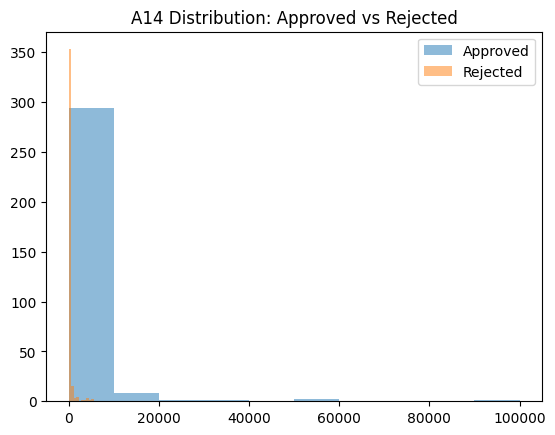

In [101]:
plt.hist(df[df['Class'] == 1]['A14'], alpha=0.5, label='Approved')
plt.hist(df[df['Class'] == 0]['A14'], alpha=0.5, label='Rejected')
plt.legend()
plt.title("A14 Distribution: Approved vs Rejected")
plt.show()

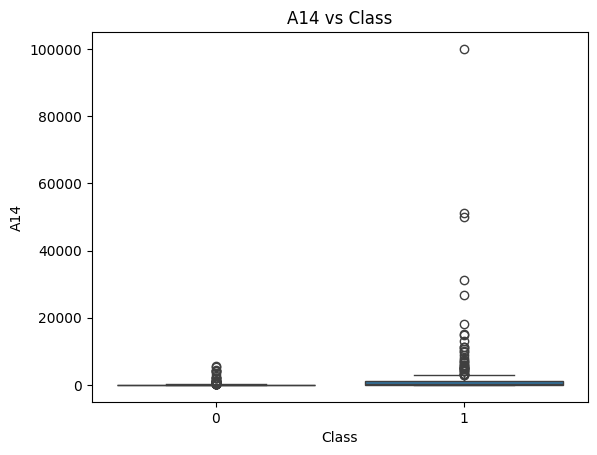

In [102]:
sns.boxplot(x='Class', y='A14', data=df)
plt.title("A14 vs Class")
plt.show()

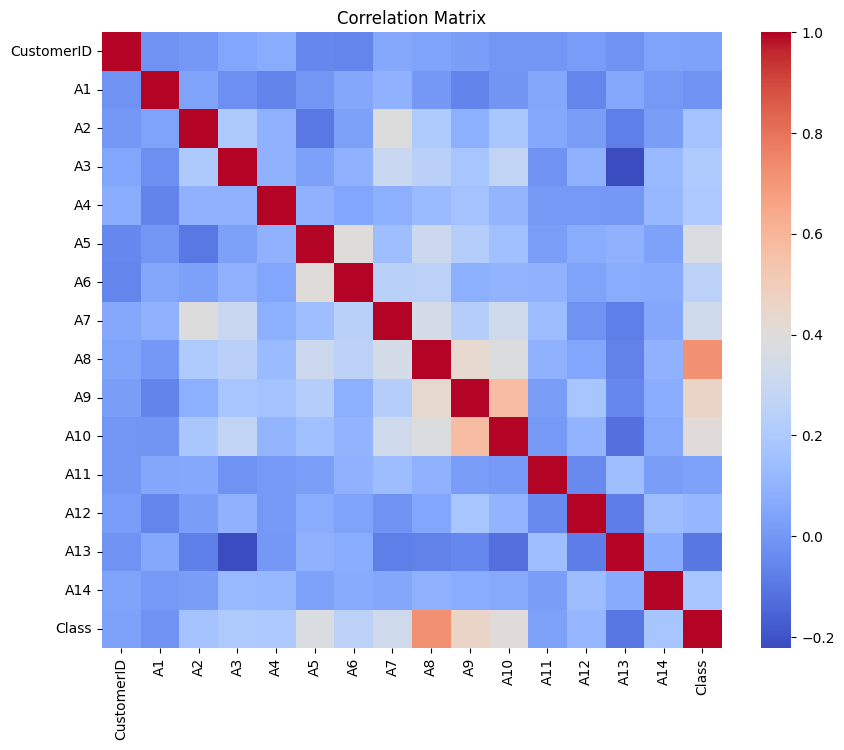

In [103]:
corr = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

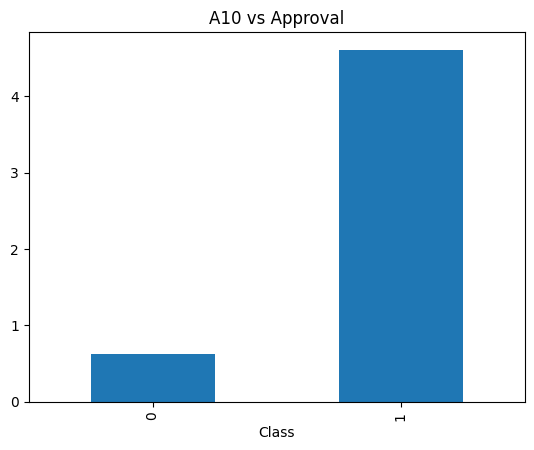

In [104]:
df.groupby('Class')['A10'].mean().plot(kind='bar')
plt.title("A10 vs Approval")
plt.show()

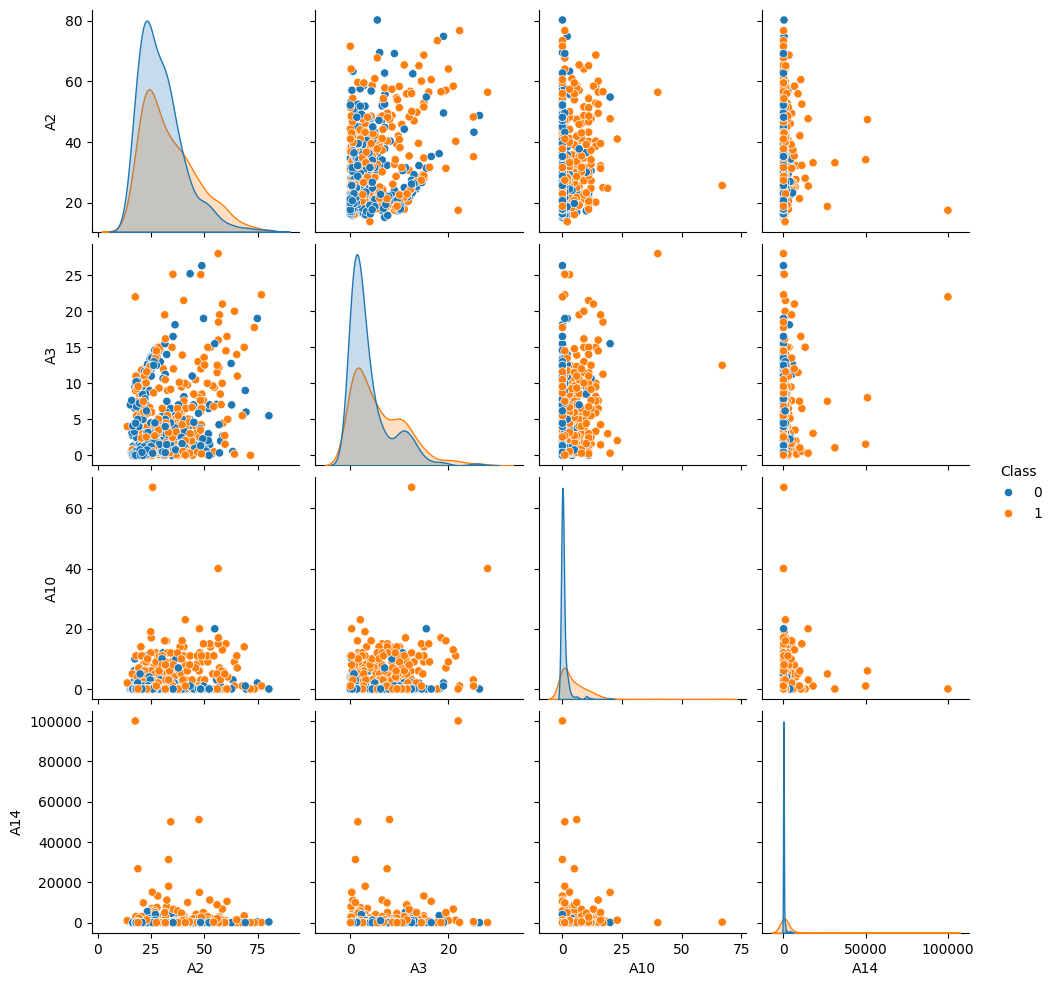

In [105]:
sns.pairplot(df[['A2', 'A3', 'A10', 'A14', 'Class']], hue='Class')
plt.show()

In [106]:
df.groupby('Class').std()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
Class,,,,,,,,,,,,,,,
0,69910.500915,0.465492,10.779092,4.337662,0.46231,3.451377,1.889925,2.120481,0.401305,0.417827,1.900049,0.497489,0.327727,179.905915,671.608839
1,73465.716181,0.470614,12.768886,5.471485,0.36594,3.377863,1.983727,4.120792,0.263690,0.466935,6.320242,0.500218,0.253565,160.199837,7659.763941


In [107]:
abs(df.corr()['Class']).sort_values(ascending=False)

Class         1.000000
A8            0.720407
A9            0.458301
A10           0.406410
A5            0.373712
A7            0.322475
A6            0.246567
A3            0.206294
A4            0.194306
A14           0.175657
A2            0.161626
A12           0.115261
A13           0.099972
CustomerID    0.035400
A11           0.031625
A1            0.013897
Name: Class, dtype: float64

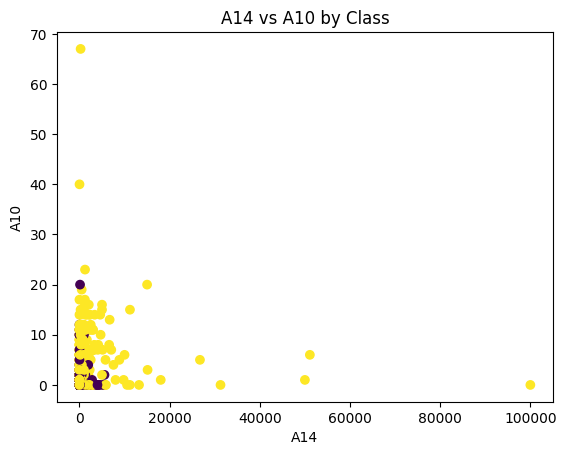

In [108]:
plt.scatter(df['A14'], df['A10'], c=df['Class'])
plt.xlabel("A14")
plt.ylabel("A10")
plt.title("A14 vs A10 by Class")
plt.show()